# Experiment 3A: Hidden Per-Spike Jitter — SHD

## Overview

This notebook implements Experiment 3A from the "Beyond Beyond Rate" project.

We train 2-hidden-layer SNNs on SHD with **per-spike Gaussian jitter applied
at the 1st hidden layer output during training**. A fresh model is trained
from scratch for each jitter level sigma — this is the same train-at-sigma
/ eval-at-sigma protocol that `docs/progress/phase1to4_fixes.md` applies to
the other notebooks, just using Gaussian jitter as the perturbation operator.

**Per-spike jitter:** each spike in the 1st hidden layer output is
independently shifted by a Gaussian-distributed offset, clipped to the
window and placed at the nearest unoccupied bin. Spike count per neuron
is approximately preserved.

**Refactor applied on `version_2` (this branch):**

- **§3.2 STE:** ``jitter_hidden_batch`` does a CPU/numpy round-trip and
  therefore returns a fresh leaf with no autograd edge. Without an STE
  wrapper, ``fc1`` receives zero gradient during training and freezes at
  random init for every sigma > 0 (Section 7.1 of the fixes doc — the
  weight-fingerprint identity in §7.1.3 was *measured on this notebook*).
  ``_apply_jitter`` is now the single source of truth.
- **§3.4 delay refactor (Option B):** ``delay1`` moved from the end of
  ``_first_hidden`` to the start of ``_second_hidden_and_output``. The
  hook now sees binary spikes directly out of ``slayer.spike``; routing
  is cleanly separated from compute.

After this refactor, the cached `data/jitter_*_sigma{1,3,...}.pt`
checkpoints are stale and must be discarded (they were trained with
`fc1` frozen at random init).

**Architecture (post-refactor):**
```
Input → fc1 → spike → [hook: jitter(sigma)] → (delay1)
      → fc2 → spike → (delay2) → fc3 → spike → output
```

**Sweep:** sigma in `SIGMA_VALUES` (ms).

A global `USE_DELAY` flag selects SGD-delay vs SGD (no delay).

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../../temporal_shd_project/code/src"))
import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here. Toggle `USE_DELAY`
to switch between SGD-delay and SGD (no delay) mode.

In [ ]:
# =====================================================================
# Batch mode: when True, the main run cell trains EVERY combination of
# (dataset_key, use_delay) listed in ALL_VARIATIONS case-by-case.
# When False, only the single (DATASET_KEY, USE_DELAY) pair below is run.
# =====================================================================
TRAIN_ALL_VARIATION: bool = False

# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay).
# Ignored when TRAIN_ALL_VARIATION is True.
# =====================================================================
USE_DELAY: bool = False

# =====================================================================
# Dataset variant: "whole", "part", or "norm".
# Ignored when TRAIN_ALL_VARIATION is True.
# =====================================================================
DATASET_KEY: str = "part"

# All (dataset_key, use_delay) pairs to iterate over in batch mode.
ALL_VARIATIONS: list[tuple[str, bool]] = [
    (dataset, delay)
    for dataset in ("norm", "part", "whole")
    for delay in (False, True)
]

# --- Dataset configurations ---
DATASET_CONFIGS = {
    "whole": {"mat_file": "../../realistic/shd/shd_data/shd_whole.mat", "input_dim": 700},
    "part":  {"mat_file": "../../realistic/shd/shd_data/shd_part_new.mat", "input_dim": 224},
    "norm":  {"mat_file": "../../realistic/shd/shd_data/shd_norm_new.mat", "input_dim": 224},
}

# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int = 128
NUM_CLASSES: int = 20
EPOCHS: int = 500
BATCH_SIZE: int = 128
LEARNING_RATE: float = 0.1
SEED: int = 42
MAX_DELAY: int = 64
EARLY_STOP_PATIENCE: int = 300

# --- Jitter sweep: sigma values in ms ---
SIGMA_VALUES: list[int] = [0, 1, 3, 5, 10, 17, 25]

# --- Evaluation ---
NUM_REPEATS: int = 3

# --- Derived names (used only when TRAIN_ALL_VARIATION is False) ---
INPUT_DIM: int = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
MAT_FILE: str = DATASET_CONFIGS[DATASET_KEY]["mat_file"]
DELAY_TAG: str = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"jitter_{DATASET_KEY}_{DELAY_TAG}"

if TRAIN_ALL_VARIATION:
    print(f"Batch mode: training {len(ALL_VARIATIONS)} variations:")
    for ds, ud in ALL_VARIATIONS:
        tag = "delay" if ud else "nodelay"
        print(f"  - jitter_{ds}_{tag}")
else:
    print(f"Single variation: dataset=SHD {DATASET_KEY} | input_dim={INPUT_DIM}")
    print(f"  Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
    print(f"  Model prefix: {MODEL_PREFIX}")
print(f"Sigma sweep: {SIGMA_VALUES}")

## 3. Load SHD Dataset

Load the dense spike-train dataset from the local `.mat` file.
Each sample has shape `(700, T)` with binary spike values.
Time dimension is padded to 200 time steps to match `tSample`.

In [3]:
def load_shd_data(mat_path: str, target_T: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Load SHD dataset from a .mat file and pad time dimension.

    Args:
        mat_path: Path to the .mat file containing 'X' and 'Y'.
        target_T: Target time dimension (pad with zeros if shorter).

    Returns:
        Tuple of (X, Y) where X has shape (N, neurons, target_T).
    """
    data = loadmat(mat_path)
    X = data["X"]
    Y = data["Y"].ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=X.dtype)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    print(f"Loaded {mat_path}: X={X.shape}, Y={Y.shape}, classes={len(np.unique(Y))}")
    return X, Y


X_all, Y_all = load_shd_data(MAT_FILE, target_T=SIM_PARAMS["tSample"])

Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_part_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20


## 4. Per-Spike Jitter Utility

The core perturbation function for Experiment 3A. Each spike in a binary spike
train is independently shifted by a random offset drawn from N(0, sigma).
The shifted time is clipped to [0, T-1] and placed at the nearest unoccupied
time bin. If no empty bin is found after `max_attempts`, the spike stays at
its original position.

This differs from Phase 2's `partial_randomize_spike_train` which relocates
a fraction of spikes to *uniformly random* positions. Here, the displacement
is *Gaussian* — small sigma preserves most timing structure while large sigma
approaches full randomisation.

In [ ]:
def jitter_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Per-spike Gaussian jitter (numpy reference implementation).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``jitter_hidden_batch`` below.

    Each spike is shifted by a random offset ~ N(0, sigma). The new time
    is clipped to [0, T-1]. If the target bin is occupied, retry up to
    ``max_attempts`` times; if all fail, keep the spike at its original time.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        sigma: Standard deviation of the Gaussian jitter (in time steps / ms).
        max_attempts: Max retries per spike to find an empty bin.

    Returns:
        Jittered spike train with same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue

        for old_time in spike_times:
            inserted = False
            attempts = 0
            while not inserted and attempts < max_attempts:
                attempts += 1
                jittered_time = int(round(old_time + np.random.normal(0, sigma)))
                jittered_time = np.clip(jittered_time, 0, T - 1)

                if new_train[neuron_idx, jittered_time] == 0:
                    new_train[neuron_idx, jittered_time] = 1
                    inserted = True

            if not inserted:
                new_train[neuron_idx, old_time] = 1

    return new_train


@torch.no_grad()
def jitter_hidden_batch(
    hidden_spikes: torch.Tensor,
    sigma: float,
    max_attempts: int = 50,
) -> torch.Tensor:
    """Vectorised GPU-side per-spike Gaussian jitter.

    For each spike in ``hidden_spikes``, draw an iid Gaussian offset
    ``~ N(0, sigma)``, shift the spike by ``round(offset)`` and clip to
    ``[0, T - 1]``. Collisions (multiple spikes landing in the same bin)
    are resolved by a priority-based tiebreaker; losing spikes are retried
    with a fresh offset for up to ``max_attempts`` outer iterations. Any
    spike still unplaced after that falls back to its original position
    (matching the numpy reference). All ops stay on the input tensor's
    device, avoiding the CPU/numpy round-trip that previously dominated
    training cost (Section 7.1.3 of ``docs/progress/phase1to4_fixes.md``).

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        sigma: Jitter std dev in time steps (ms). 0 means no jitter.
        max_attempts: Outer retry budget per spike before fallback.

    Returns:
        Jittered tensor with the same shape, dtype and device.
    """
    if sigma <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5  # (B, C, T) bool

    new_spikes = torch.zeros_like(is_spike)
    unplaced = is_spike.clone()

    t_idx = torch.arange(T, device=x.device).view(1, 1, T)
    inf_tensor = torch.full_like(x, float("inf"))

    for _ in range(max_attempts):
        if not unplaced.any():
            break

        # Sample iid Gaussian targets for every position; positions that are
        # not currently unplaced are ignored downstream via the priority mask.
        offsets = torch.randn_like(x) * sigma
        target = (t_idx + offsets).round().long().clamp(0, T - 1)

        # Tiebreaker: each unplaced source gets a random priority; for every
        # target bin, the lowest-priority source wins. Non-unplaced sources
        # get +inf so they never win.
        priority = torch.where(unplaced, torch.rand_like(x), inf_tensor)
        min_priority = inf_tensor.clone()
        min_priority.scatter_reduce_(
            -1, target, priority, reduce="amin", include_self=True,
        )

        # A source wins iff its priority equals its target's min AND the
        # target bin is still free (not already placed in this or prior pass).
        target_min = min_priority.gather(-1, target)
        target_free = ~new_spikes.gather(-1, target)
        wins = unplaced & (priority == target_min) & target_free

        # Scatter winning sources onto their target positions.
        scatter_out = torch.zeros((B, C, T), device=x.device, dtype=torch.uint8)
        scatter_out.scatter_add_(-1, target, wins.to(torch.uint8))
        new_spikes = new_spikes | (scatter_out > 0)

        unplaced = unplaced & ~wins

    # Fallback: any source spike still unplaced after the retry budget stays
    # at its original time bin (collapses harmlessly under OR).
    new_spikes = new_spikes | unplaced

    return new_spikes.to(hidden_spikes.dtype).view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. All splits use **unperturbed** input data — the jitter is applied at the
hidden layer inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and build train/val/test DataLoaders.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for all loaders.
        seed: Random seed for train shuffle.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    N = len(Y)
    train_idx = get_split_indices(TRAIN_RANGE, N)
    val_idx = get_split_indices(VAL_RANGE, N)
    test_idx = get_split_indices(TEST_RANGE, N)

    np.random.seed(seed)
    np.random.shuffle(train_idx)

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SHD architecture, with
`delay1` repositioned per §3.4 Option B so the perturbation hook sits
directly after `slayer.spike` on the 1st hidden layer.

```
Input → [PSP + fc1 + spike] → hidden1 spikes  ← [hook: jitter(sigma)]
      → [delay1 + PSP + fc2 + spike] → (delay2) → hidden2 spikes
      → [PSP + fc3 + spike] → output
```

`forward(x, sigma)` routes the hidden spikes through `_apply_jitter` — a
straight-through estimator that uses the jittered tensor as the forward
value but lets gradients flow back through the unperturbed `hidden1`.
Without this, `fc1` stays at random init for any `sigma > 0`.

In [ ]:
class JitterSHDNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN with per-spike jitter at the 1st hidden layer.

    ``delay1`` is applied at the start of ``_second_hidden_and_output``
    (§3.4 Option B) so the perturbation hook sees the 1st hidden layer's
    binary spike output directly. ``forward(x, sigma)`` applies the jitter
    through a straight-through estimator so ``fc1`` still receives gradient
    when training at ``sigma > 0`` (§3.2 / §7.1 of the fixes doc).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 20,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # delay1 lives at the start of _second_hidden_and_output (after the
        # perturbation hook); delay2 stays between fc2-spike and fc3.
        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> hidden1 spikes (strictly binary)."""
        return self.slayer.spike(self.fc1(self.slayer.psp(x)))

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> (delay1) -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = hidden1
        if self.use_delay:
            x = self.delay1(x)
        x = self.slayer.spike(self.fc2(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def _apply_jitter(
        self,
        hidden: torch.Tensor,
        sigma: float,
    ) -> torch.Tensor:
        """STE wrapper around ``jitter_hidden_batch``.

        ``jitter_hidden_batch`` goes through numpy, so the returned tensor
        is a fresh leaf with no autograd edge. Without this wrapper,
        ``loss.backward()`` cannot propagate gradient back to ``fc1`` and
        the upstream layer stays at random init for the whole training
        run at any ``sigma > 0`` (Section 7.1 of the fixes doc — the
        weight-fingerprint identity in §7.1.3 came from this notebook).
        Forward value is the jittered tensor; backward gradient is the
        identity through ``hidden``.
        """
        if sigma <= 0:
            return hidden
        jittered = jitter_hidden_batch(hidden, sigma)
        return hidden + (jittered - hidden).detach()

    def forward(
        self,
        x: torch.Tensor,
        sigma: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with per-spike jitter at the 1st hidden layer.

        Args:
            x: Input spike trains.
            sigma: Jitter std dev in ms. 0 means no jitter.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        hidden1 = self._apply_jitter(hidden1, sigma)
        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train the model with per-spike jitter applied at the 1st hidden layer output
during every forward pass. The jitter sigma is constant throughout training
for a given model. Uses SLAYER's `NumSpikes` loss with Nadam optimiser and
adaptive delay clamping (matching the original SHD training script).

In [7]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: JitterSHDNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build NumSpikes loss, Nadam optimizer, and LR scheduler.

    Args:
        net: The network to optimize.
        lr: Base learning rate.

    Returns:
        Tuple of (loss_fn, optimizer, scheduler).
    """
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    sigma: float,
    input_dim: int = INPUT_DIM,
    hidden_units: int = HIDDEN_UNITS,
    num_classes: int = NUM_CLASSES,
    use_delay: bool = USE_DELAY,
    max_delay: int = MAX_DELAY,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    seed: int = SEED,
    patience: int = EARLY_STOP_PATIENCE,
) -> tuple[JitterSHDNetwork, dict]:
    """Train a JitterSHDNetwork with hidden-layer jitter.

    A new model is created and trained from scratch. Per-spike jitter
    with the given sigma is applied at the 1st hidden layer during
    every training forward pass.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        sigma: Jitter std dev applied at hidden layer during training.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        lr: Learning rate.
        seed: Random seed.
        patience: Early stopping patience.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = JitterSHDNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "delay_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Training sigma={sigma}") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            batch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                # Forward with hidden-layer jitter
                outputs = net(x_batch, sigma=sigma)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())
                pbar.update(1)

            # --- Adaptive delay clamping ---
            if use_delay:
                if epoch <= 250:
                    net.clamp_delays(max_delay, max_delay)
                else:
                    update1 += 1
                    update2 += 1
                    for name, param in net.named_parameters():
                        if "delay1.delay" in name and update1 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea1_val = torch.max(sorted_)
                            if sorted_[108] > (thea1_val - 5):
                                thea1 = int(thea1_val.item()) + 1
                                update1 = 0
                        elif "delay2.delay" in name and update2 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea2_val = torch.max(sorted_)
                            if sorted_[108] > (thea2_val - 5):
                                thea2 = int(thea2_val.item()) + 1
                                update2 = 0
                    net.clamp_delays(thea1, thea2)

            # --- Validate (with same jitter) ---
            net.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = (
                        x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                    )
                    y_batch = y_batch.to(device).long()

                    target = torch.zeros(
                        (len(y_batch), num_classes, 1, 1, 1), device=device
                    )
                    target.scatter_(
                        1, y_batch[:, None, None, None, None], 1.0
                    )

                    outputs = net(x_batch, sigma=sigma)
                    val_loss += loss_fn.numSpikes(outputs, target).item()

                    pred = snn.predict.getClass(outputs)
                    correct += (pred.cpu() == y_batch.cpu()).sum().item()
                    total += len(y_batch)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / max(1, total)
            train_loss = np.mean(batch_losses)

            # Log delay statistics
            delays = net.get_delays()
            avg_delay = (
                np.mean([
                    np.mean(d) for d in delays.values() if len(d) > 0
                ])
                if delays
                else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(float(train_loss))
            log["val_loss"].append(float(val_loss))
            log["val_acc"].append(float(val_acc))
            log["delay_mean"].append(float(avg_delay))

            pbar.set_postfix(
                epoch=epoch + 1,
                train=f"{train_loss:.3f}",
                val=f"{val_loss:.3f}",
                acc=f"{val_acc:.2%}",
                delay=f"{avg_delay:.1f}",
            )
            scheduler.step()

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.clone() for k, v in net.state_dict().items()
                }
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing

Evaluate a trained model on the test set with hidden-layer jitter at the
same sigma it was trained on. Repeated evaluations with different random
seeds provide error bars.

In [8]:
def test_with_jitter(
    net: JitterSHDNetwork,
    test_loader: DataLoader,
    sigma: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer jitter at level sigma.

    Args:
        net: Trained JitterSHDNetwork.
        test_loader: Test DataLoader.
        sigma: Jitter std dev applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net(x_batch, sigma=sigma)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: JitterSHDNetwork,
    test_loader: DataLoader,
    sigma: float,
    num_repeats: int = NUM_REPEATS,
) -> dict:
    """Evaluate with jitter multiple times for error bars.

    Args:
        net: Trained network.
        test_loader: Test DataLoader.
        sigma: Jitter std dev.
        num_repeats: Number of independent evaluations.

    Returns:
        Dict with "mean", "std", and "values".
    """
    accuracies = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        acc = test_with_jitter(net, test_loader, sigma=sigma)
        accuracies.append(acc)

    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": accuracies,
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. jitter sigma across all trained models (the main result).

In [9]:
def plot_training_curves(log: dict, sigma: float) -> None:
    """Plot training / validation loss, accuracy, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid(True, alpha=0.3)

    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title("Average Delay Over Training")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SHD {DATASET_KEY} ({DELAY_TAG}) — Hidden Jitter sigma={sigma}", fontsize=14
    )
    plt.tight_layout()
    plt.show()


def plot_jitter_sweep_curve(
    sweep_results: dict[int, dict],
) -> None:
    """Plot accuracy vs hidden jitter sigma across all trained models."""
    sigma_vals = sorted(sweep_results.keys())
    means = [sweep_results[s]["mean"] for s in sigma_vals]
    stds = [sweep_results[s]["std"] for s in sigma_vals]

    color = "tab:orange" if USE_DELAY else "tab:blue"
    label = f"SGD-delay ({DATASET_KEY})" if USE_DELAY else f"SGD ({DATASET_KEY})"

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        sigma_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Jitter Sigma (ms)")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 3A: SHD {DATASET_KEY} — Accuracy vs Hidden Per-Spike Jitter ({DELAY_TAG})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for s, mean, std in zip(sigma_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (s, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = f"log/{MODEL_PREFIX}_jitter_sweep.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train Models for Each Sigma (per variation)

`run_variation_sweep` wraps the full per-variation pipeline — load data,
build dataloaders, train one fresh model per sigma in `SIGMA_VALUES`,
save the checkpoint and the JSON sweep result. When
`TRAIN_ALL_VARIATION` is `True`, it is called once for every
(dataset_key, use_delay) pair in `ALL_VARIATIONS` (6 variations total) so
you can launch the whole grid in a single cell. Otherwise it runs once on
the configured `(DATASET_KEY, USE_DELAY)` pair.

Each variation persists its own files under `data/` and `log/`:
- `data/jitter_{dataset}_{tag}_sigma{sigma}.pt`
- `log/jitter_{dataset}_{tag}_jitter_sweep_results.json`
- `log/jitter_{dataset}_{tag}_sigma{sigma}_training_log.json`

In-memory state (`all_trained_models`, `all_training_logs`,
`all_test_results`, `test_loader`) mirrors the *last* variation run, so
the downstream diagnostic / plotting / analysis cells operate on it.

In [ ]:
def run_variation_sweep(
    dataset_key: str,
    use_delay: bool,
) -> dict:
    """Train-at-sigma sweep for one (dataset_key, use_delay) variation.

    Loads the SHD variant, builds dataloaders, trains one fresh model per
    sigma in SIGMA_VALUES with hidden-layer jitter active during training
    (via the STE), evaluates each at the same sigma, and persists
    per-variation checkpoints + JSON.

    Args:
        dataset_key: One of "norm", "part", "whole".
        use_delay: Train the SGD-delay variant if True, else SGD.

    Returns:
        Dict with models / logs / results / test_loader / model_prefix
        / dataset_key / use_delay for the variation.
    """
    cfg = DATASET_CONFIGS[dataset_key]
    input_dim = cfg["input_dim"]
    mat_file = cfg["mat_file"]
    delay_tag = "delay" if use_delay else "nodelay"
    model_prefix = f"jitter_{dataset_key}_{delay_tag}"

    print(f"\n{'#' * 70}")
    print(f"# Variation: dataset={dataset_key} | delay={delay_tag}")
    print(f"# Model prefix: {model_prefix}")
    print(f"{'#' * 70}")

    X, Y = load_shd_data(mat_file, target_T=SIM_PARAMS["tSample"])
    train_loader, val_loader, test_loader = build_dataloaders(
        X, Y, batch_size=BATCH_SIZE, seed=SEED,
    )

    models: dict[int, JitterSHDNetwork] = {}
    logs: dict[int, dict] = {}
    results: dict[int, dict] = {}

    for sigma in SIGMA_VALUES:
        print(f"\n{'=' * 60}")
        print(f"  Training {model_prefix} with hidden jitter sigma={sigma} ms")
        print(f"{'=' * 60}")

        net, training_log = train_model(
            train_loader=train_loader,
            val_loader=val_loader,
            sigma=sigma,
            input_dim=input_dim,
            hidden_units=HIDDEN_UNITS,
            num_classes=NUM_CLASSES,
            use_delay=use_delay,
            max_delay=MAX_DELAY,
            epochs=EPOCHS,
            lr=LEARNING_RATE,
            seed=SEED,
            patience=EARLY_STOP_PATIENCE,
        )

        model_path = f"data/{model_prefix}_sigma{sigma}.pt"
        torch.save(net.state_dict(), model_path)
        print(f"Model saved to {model_path}")

        test_result = test_with_repeats(net, test_loader, sigma=sigma)
        print(
            f"sigma={sigma} | Test Accuracy: "
            f"{test_result['mean']:.4f} +/- {test_result['std']:.4f}"
        )

        models[sigma] = net
        logs[sigma] = training_log
        results[sigma] = test_result

    # Persist sweep results
    sweep_serialisable = {
        str(sigma): {
            "mean": float(d["mean"]),
            "std": float(d["std"]),
            "values": [float(v) for v in d["values"]],
        }
        for sigma, d in results.items()
    }
    results_path = f"log/{model_prefix}_jitter_sweep_results.json"
    with open(results_path, "w") as fp:
        json.dump(sweep_serialisable, fp, indent=2)
    print(f"\nSweep results saved to {results_path}")

    # Persist per-sigma training logs
    for sigma, log in logs.items():
        log_path = f"log/{model_prefix}_sigma{sigma}_training_log.json"
        log_serialisable = {
            k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
            for k, vals in log.items()
        }
        with open(log_path, "w") as fp:
            json.dump(log_serialisable, fp, indent=2)
        print(f"  Training log saved to {log_path}")

    return {
        "models": models,
        "logs": logs,
        "results": results,
        "test_loader": test_loader,
        "model_prefix": model_prefix,
        "dataset_key": dataset_key,
        "use_delay": use_delay,
    }


os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

variations_to_run = (
    ALL_VARIATIONS if TRAIN_ALL_VARIATION else [(DATASET_KEY, USE_DELAY)]
)

all_variation_runs: dict[tuple[str, bool], dict] = {}
for _ds_key, _use_delay in variations_to_run:
    _run = run_variation_sweep(_ds_key, _use_delay)
    all_variation_runs[(_ds_key, _use_delay)] = _run

# Expose the most recent variation's state under the names the downstream
# diagnostic / plotting / analysis cells use.
all_trained_models = _run["models"]
all_training_logs = _run["logs"]
all_test_results = _run["results"]
test_loader = _run["test_loader"]

## 10b. Diagnostic — STE Health Check

Per §3.6 / §5 of `docs/progress/phase1to4_fixes.md`. If two `sigma > 0`
rows show bit-identical `fc1.norm` (to 4 decimals), the STE didn't take
and `fc1` is still frozen at random init — go back to §3.2 in the
fixes doc. `hidden_unique` should be `[0.0, 1.0]` — non-binary values
mean the §3.4 delay refactor regressed.

In [ ]:
print(f"{'sigma':>6}  {'fc1.norm':>10}  hidden_unique")
for sigma_val, mdl in all_trained_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        x_b = x_b.unsqueeze(2).unsqueeze(3).float().to(device)
        hidden = mdl._first_hidden(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(f"{sigma_val:>6}  {fc1_norm:>10.4f}  {unique}")

## 11. Plot Training Curves

Show training curves for each sigma value.


--- Training curves for sigma=0 ---


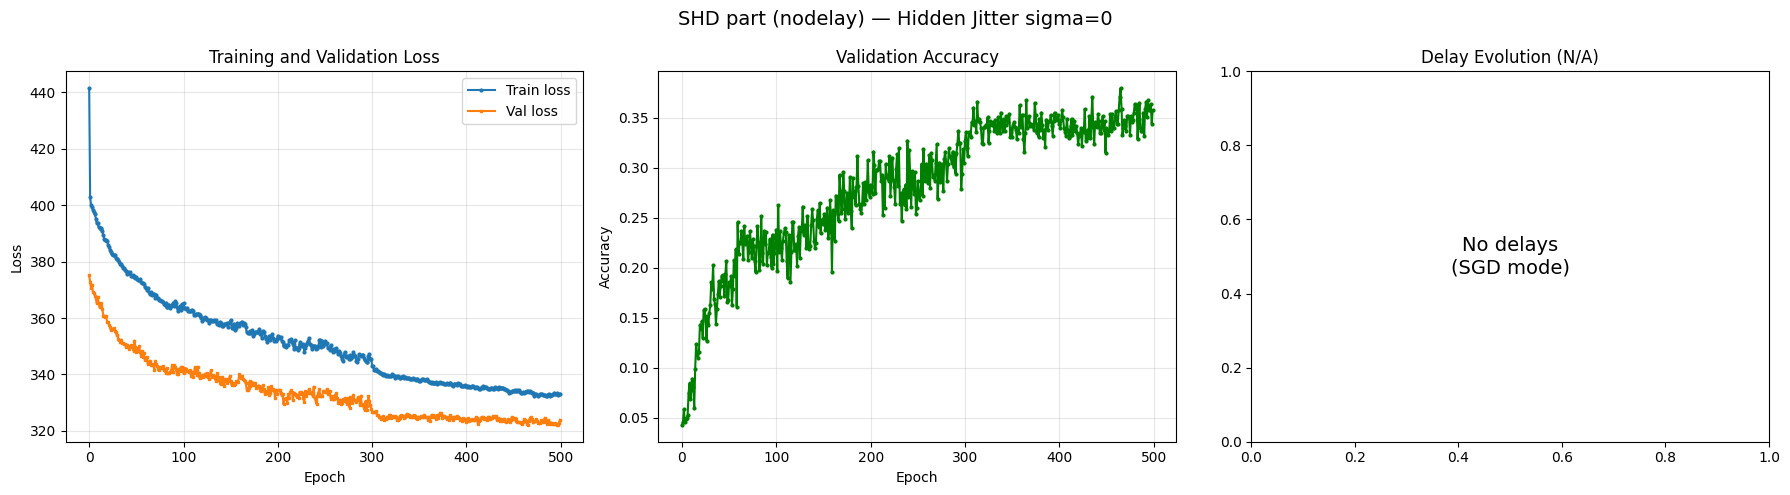


--- Training curves for sigma=1 ---


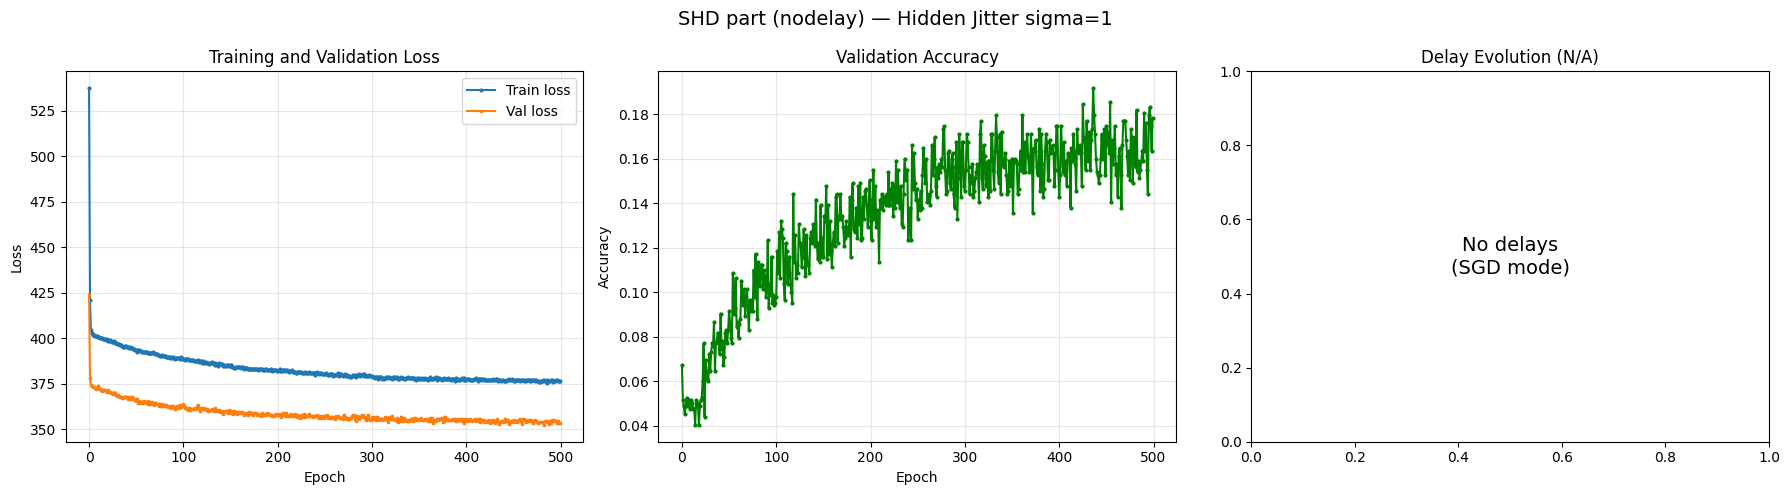


--- Training curves for sigma=3 ---


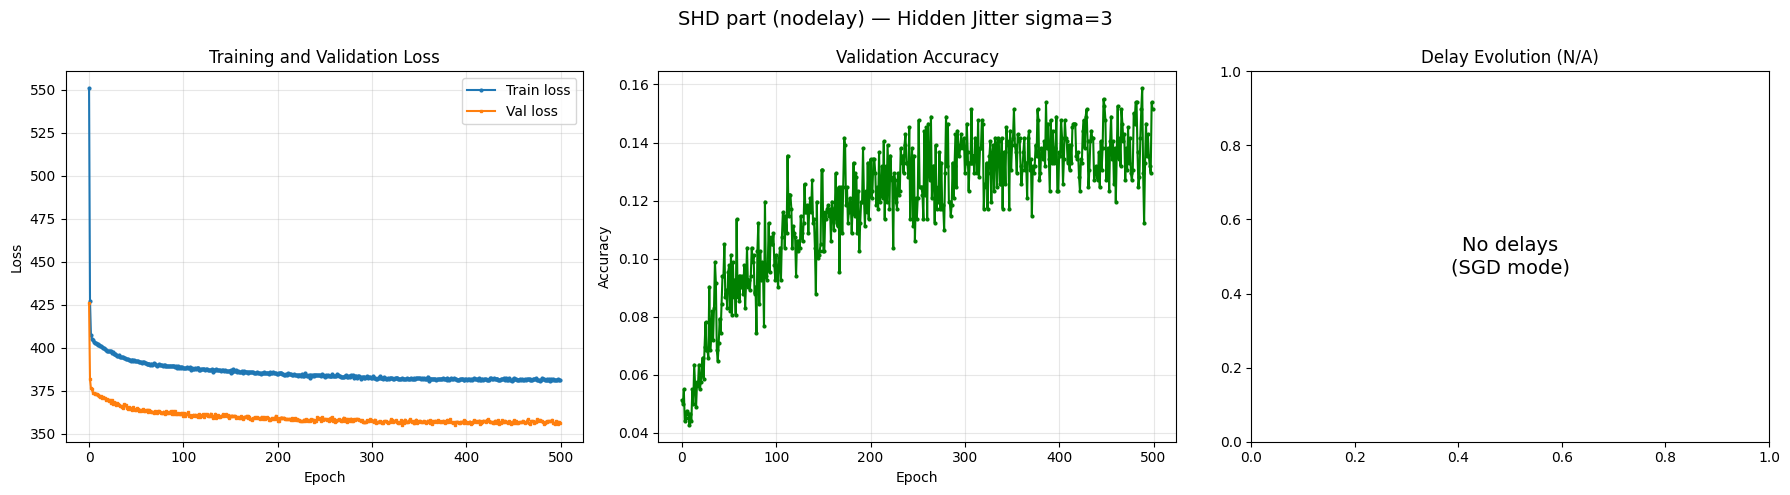


--- Training curves for sigma=5 ---


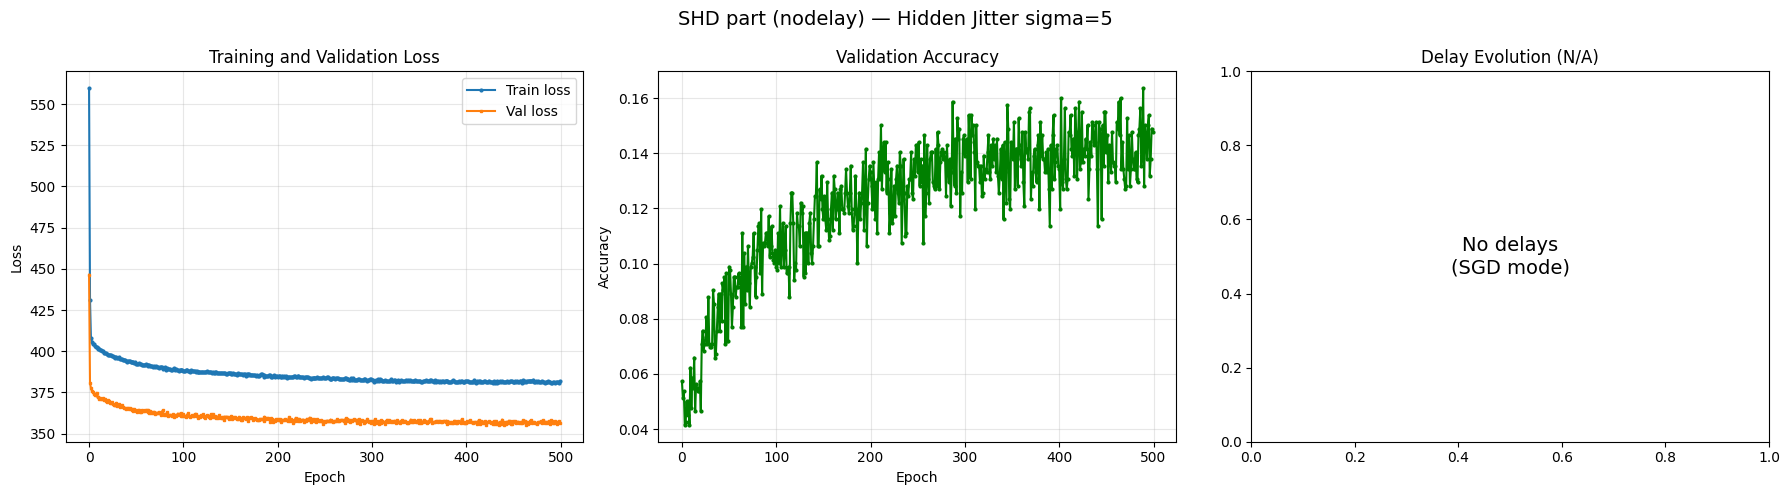


--- Training curves for sigma=10 ---


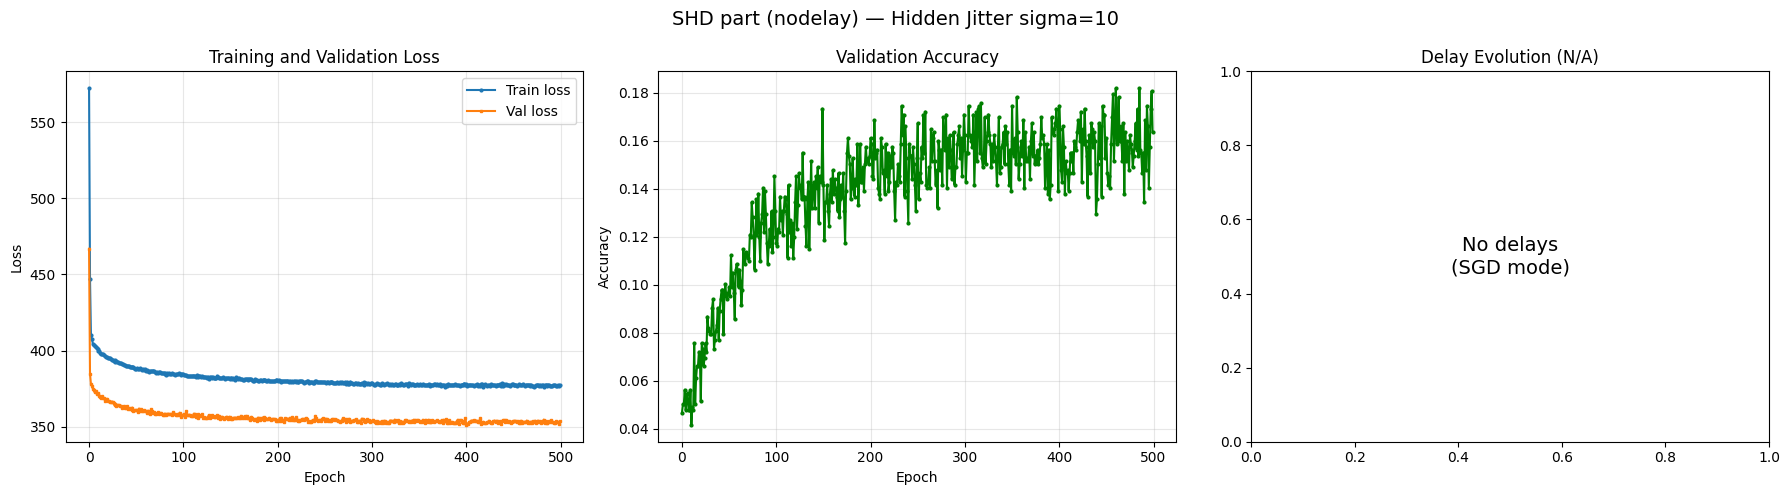


--- Training curves for sigma=17 ---


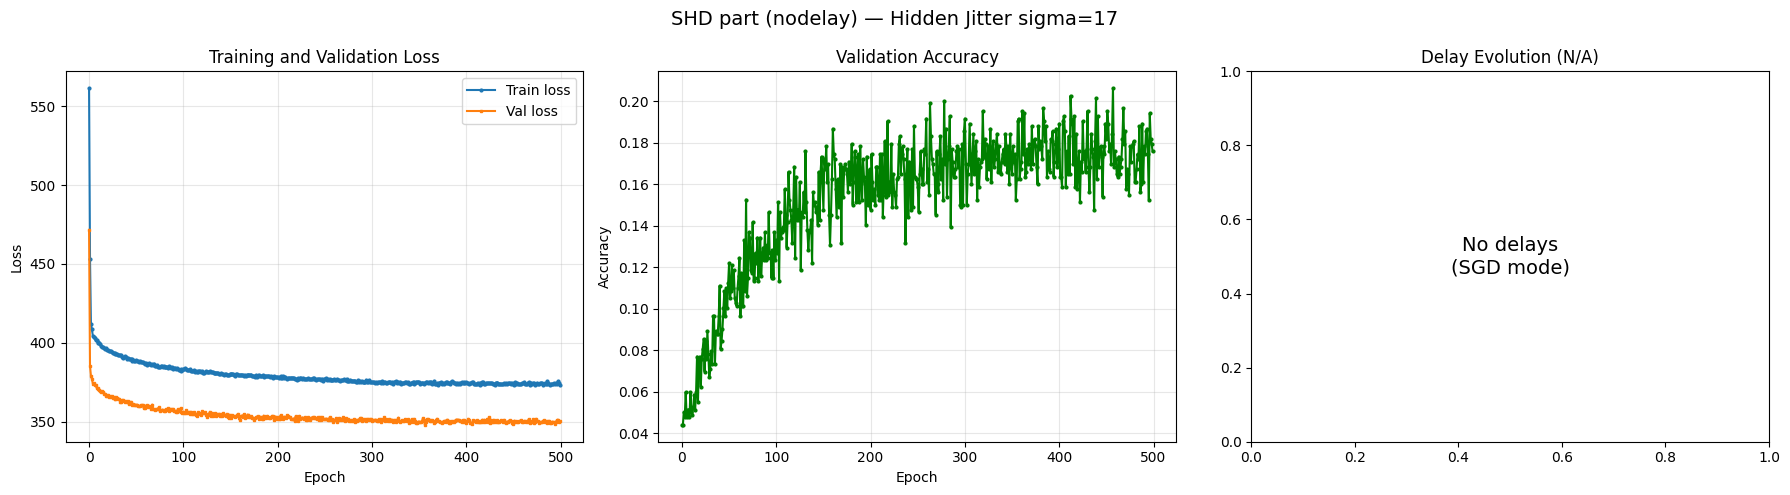


--- Training curves for sigma=25 ---


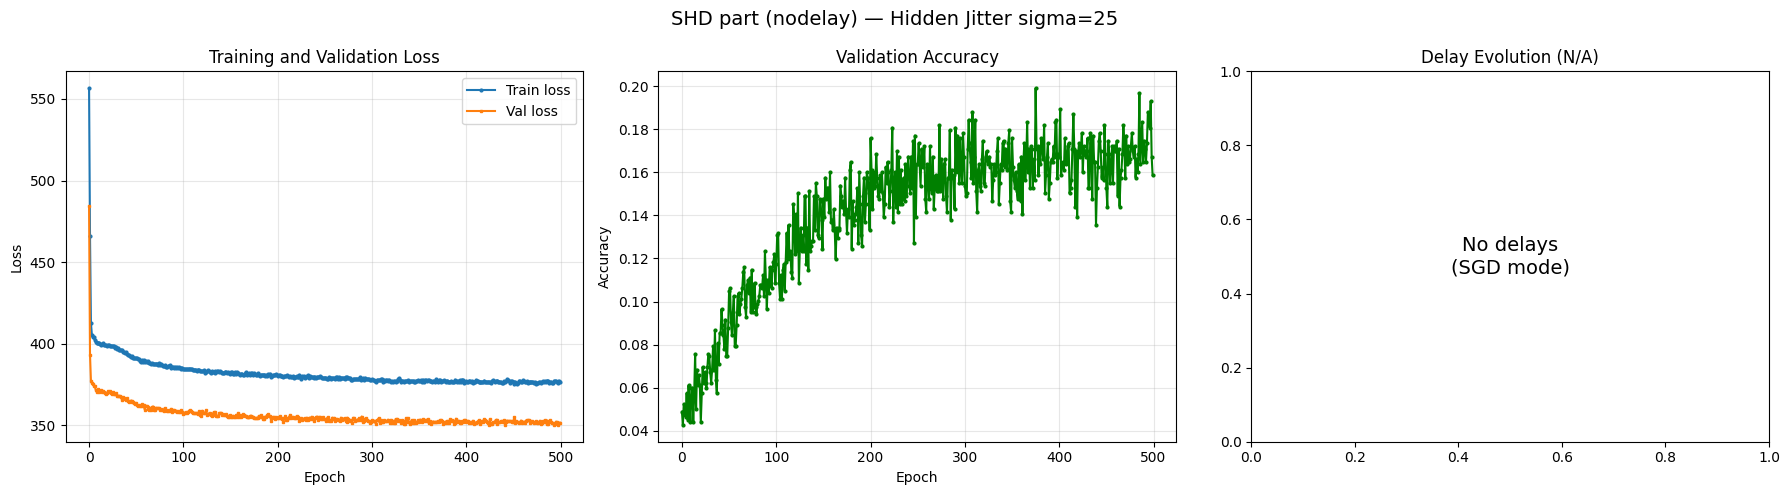

In [11]:
for sigma in SIGMA_VALUES:
    print(f"\n--- Training curves for sigma={sigma} ---")
    plot_training_curves(all_training_logs[sigma], sigma=sigma)

## 12. Plot Jitter Sweep Results

The main result: test accuracy vs. hidden-layer jitter sigma across
all trained models.

**Interpretation:**
- If accuracy degrades with increasing sigma: the network's internal
  representation relies on precise spike timing.
- If accuracy stays flat: the hidden layer has collapsed temporal info
  to a rate code (since jitter preserves spike counts).
- Compare SGD-delay vs SGD (run notebook twice with different `USE_DELAY`)
  to see if delays lead to richer internal temporal codes.

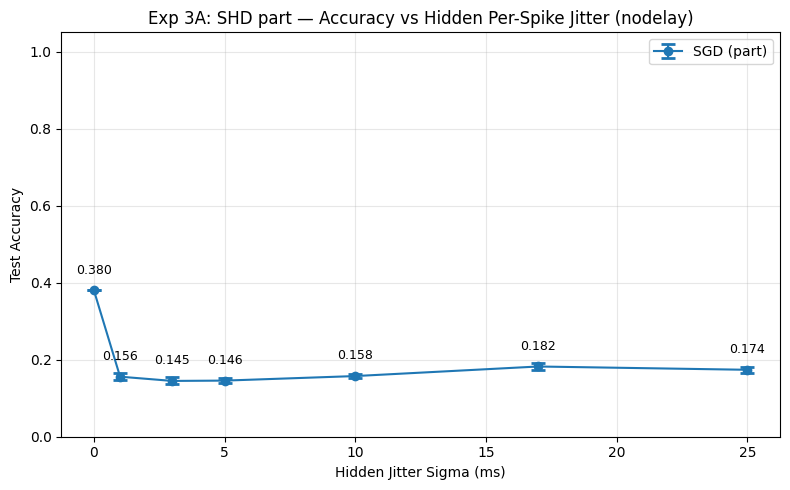

Figure saved to log/jitter_part_nodelay_jitter_sweep.png


In [12]:
plot_jitter_sweep_curve(all_test_results)

## 13. Save Results

Saving is performed inside `run_variation_sweep` (per-variation files
under `data/` and `log/`), so no extra save step is needed here.

## 14. Model Analysis

Print delay statistics and weight statistics for each trained model.

In [14]:
for sigma in SIGMA_VALUES:
    net = all_trained_models[sigma]
    print(f"\n{'='*60}")
    print(f"  Model Analysis — sigma={sigma} ({DELAY_TAG})")
    print(f"{'='*60}")

    # Delay statistics
    delays = net.get_delays()
    if delays:
        for delay_name, delay_values in delays.items():
            if len(delay_values) > 0:
                print(
                    f"  {delay_name}: "
                    f"mean={np.mean(delay_values):.2f}, "
                    f"std={np.std(delay_values):.2f}, "
                    f"min={np.min(delay_values):.2f}, "
                    f"max={np.max(delay_values):.2f}"
                )
    else:
        print("  No delays (SGD mode)")

    # Weight statistics
    for name, param in net.named_parameters():
        if "weight" in name:
            w = param.data
            print(
                f"  {name}: mean={w.mean().item():.4f}, "
                f"std={w.std().item():.4f}, "
                f"shape={list(w.shape)}"
            )


  Model Analysis — sigma=0 (nodelay)
  No delays (SGD mode)
  fc1.weight_g: mean=14.6847, std=14.5894, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=-0.6226, std=6.1113, shape=[128, 224, 1, 1, 1]
  fc2.weight_g: mean=22.8948, std=31.4185, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=0.0048, std=2.9706, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=66.7173, std=16.5914, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=-0.2141, std=4.2643, shape=[20, 128, 1, 1, 1]

  Model Analysis — sigma=1 (nodelay)
  No delays (SGD mode)
  fc1.weight_g: mean=5.7758, std=0.1568, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=-0.0000, std=0.3861, shape=[128, 224, 1, 1, 1]
  fc2.weight_g: mean=26.2640, std=37.0950, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.4329, std=4.7054, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=61.9690, std=12.2391, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=0.6438, std=5.2596, shape=[20, 128, 1, 1, 1]

  Model Analysis — sigma=3 (nodelay)
  No delays (SGD mode)
  fc1.weight_g: